In [17]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# Data Preprocessing

## Combining Datasets

In [18]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

In [19]:
df_guardian = pd.read_csv('individual data/guardian_neurodivergence_all_v2.csv')
guardian_df = df_guardian[['movie_title', 'article_text']].rename(columns={'article_text': 'text'})
guardian_df['source'] = 'guardian'
guardian_df.head()

,movie_title,text,source
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian
3,Atypical,The sinister segregation policies excluding ch...,guardian
4,Atypical,This week’s best home entertainment: from Vani...,guardian


In [20]:
df_reddit = pd.read_csv('individual data/reddit_movie_posts_filtered.csv')
reddit_comments_df = df_reddit[['movie_title', 'comments_text']].rename(columns={'comments_text': 'text'})
reddit_comments_df['source'] = 'reddit'
reddit_selftext_df = df_reddit[['movie_title', 'selftext']].rename(columns={'selftext': 'text'})
reddit_selftext_df['source'] = 'reddit'
df_reddit.head()

,movie_title,movie_type,reddit_id,title,selftext,comments_text,mention_count,mention_count_comments,url,score,num_comments,subreddit
0,Atypical,tv,17xb1hv,"Atypical, the series, is trash","I don't know about the later seasons, but I ju...","I really enjoyed it, and found Sam relatable. ...",1,6,https://www.reddit.com/r/aspergers/comments/17...,64,51,aspergers
1,Atypical,tv,ajae2b,Anyone else hate “Atypical”?,Everyone with ASD that I’ve met who watched th...,It’s not possible to accurately represent a di...,2,0,https://www.reddit.com/r/autism/comments/ajae2...,13,18,autism
2,Atypical,tv,6u5s1v,[ALL] Surprise! Surprise! People are bitching ...,- http://www.teenvogue.com/story/netflix-atypi...,"I haven't seen the show yet, but there's a say...",3,2,https://www.reddit.com/r/netflix/comments/6u5s...,165,68,netflix
3,Atypical,tv,ogks6j,Is Atypical (Netflix Series) accurate in it's ...,Since season 4 starts today (9th July) I was w...,The sister (unintentionally?) seems like a mor...,1,2,https://www.reddit.com/r/aspergers/comments/og...,70,68,aspergers
4,Atypical,tv,1icodms,What's your opinion on the show Atypical,I recently found this show on Netflix called A...,"Hey /u/Alternative_Rate9624, thank you for you...",2,1,https://www.reddit.com/r/autism/comments/1icod...,1,10,autism


In [21]:
# Combine the two text sources (selftext + comments_text)
reddit_combined_df = pd.concat([
    df_reddit[['movie_title', 'selftext']].rename(columns={'selftext': 'text'}),
    df_reddit[['movie_title', 'comments_text']].rename(columns={'comments_text': 'text'})
], ignore_index=True)
reddit_combined_df['source'] = 'reddit'
# Drop rows where 'text' is missing or empty
reddit_combined_df = reddit_combined_df.dropna(subset=['text'])
reddit_combined_df = reddit_combined_df[reddit_combined_df['text'].astype(str).str.strip() != ""]

# Reset index
reddit_combined_df = reddit_combined_df.reset_index(drop=True)

# Display the clean result
display(reddit_combined_df.head())

,movie_title,text,source
0,Atypical,"I don't know about the later seasons, but I ju...",reddit
1,Atypical,Everyone with ASD that I’ve met who watched th...,reddit
2,Atypical,- http://www.teenvogue.com/story/netflix-atypi...,reddit
3,Atypical,Since season 4 starts today (9th July) I was w...,reddit
4,Atypical,I recently found this show on Netflix called A...,reddit


In [22]:
df_wiki = pd.read_csv('individual data/Wiki_Talk_has_duplicates.csv')
wiki_df = df_wiki[['movie_title', 'text']].rename(columns={'text': 'text'})
wiki_df['source'] = 'wikitalks'
guardian_df.head()

,movie_title,text,source
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian
3,Atypical,The sinister segregation policies excluding ch...,guardian
4,Atypical,This week’s best home entertainment: from Vani...,guardian


In [23]:
df_yt = pd.read_excel('individual data/youtube_comments.xlsx')
youtube_df = df_yt[['movie', 'Reviews']].rename(columns={'movie': 'movie_title', 'Reviews': 'text'})
youtube_df['source'] = 'youtube'
youtube_df.head()

,movie_title,text,source
0,Atypical (Netflix Series),I love this show. As a high functioning autist...,youtube
1,Atypical (Netflix Series),"Don't worry, it's the autism speaking and accu...",youtube
2,Atypical (Netflix Series),"As an autistic person, mostly high functioning...",youtube
3,Atypical (Netflix Series),“Dude nobody’s normal” as a woman with autism....,youtube
4,Atypical (Netflix Series),I have two autistic teenagers. I liked so much...,youtube


## Cleaning Dataset

In [24]:
# Mapping from old movie names to clean standardized names
movie_name_map = {
    'Atypical (Netflix Series)': 'Atypical',
    'The Good Doctor (ABC Series)': 'The Good Doctor',
    'Temple Grandin (HBO Movie)': 'Temple Grandin',
    "Everything's Gonna Be Okay (Freeform Series)": "Everything's Gonna Be Okay",  # optional, if you still have this one
    'Taare Zameen Par (Bollywood Film)': 'Taare Zameen Par',
    'Sitare Zameen Par (Bollywood Film)': 'Sitare Zameen Par',
    'Front of the Class (Hallmark Movie)': 'Front of the Class',
    'Patience (2017 Film)': 'Patience',
    'Barfi! (Bollywood Film)': 'Barfi',
    'My Name is Khan (Bollywood Film)': 'My Name is Khan',
    'Music (Sia Film)': 'Music',
    'Hichki (Bollywood Film)': 'Hichki',
    'Rain Man (1988 Film)': 'Rain Man',
    'Extraordinary Attorney Woo (Korean Series)': 'Extraordinary Attorney Woo',
}

# Optional: If you need to add missing titles not present in YouTube
extra_titles = ['The Tic Code', 'Koi... Mil Gaya']

youtube_df['movie_title'] = youtube_df['movie_title'].replace(movie_name_map)

print("Unique cleaned movie titles:")
print(youtube_df['movie_title'].unique())


Unique cleaned movie titles:
['Atypical' 'The Good Doctor' 'Temple Grandin'
 "Everything's Gonna Be Okay" 'Taare Zameen Par' 'Sitare Zameen Par'
 'Front of the Class' 'Patience' 'Barfi' 'My Name is Khan' 'Music'
 'Hichki' 'Rain Man' 'Extraordinary Attorney Woo']


In [25]:
#Combining data
combined_df = pd.concat([guardian_df, reddit_combined_df, wiki_df,youtube_df], ignore_index=True)

In [26]:
combined_df["source"].value_counts()
combined_df["movie_title"].value_counts()

movie_title
Music                         10642
Atypical                        864
Temple Grandin                  468
Extraordinary Attorney Woo      441
Patience                        416
Sitare Zameen Par               288
Hichki                          249
Rain Man                        174
Taare Zameen Par                172
The Good Doctor                 163
Everything's Gonna Be Okay      149
My Name is Khan                  99
Front of the Class               71
Barfi                            64
The Tic Code                     24
Koi... Mil Gaya                  22
Name: count, dtype: int64

In [27]:

combined_df[combined_df['text'].isnull()]
combined_df = combined_df.dropna().reset_index(drop=True)
combined_df.isnull().sum()


movie_title    0
text           0
source         0
dtype: int64

In [28]:
movie_old_db = pd.read_csv('data cleaning duplicates/Movies_cleaned.csv')

In [29]:
movie_old_db.head()

,Move_TV_Show,Source,Review,cleaned_Review
0,The good doctor,IMDB,I have ASD and I wish I watched this sooner. J...,I have ASD and I wish I watched this sooner J...
1,The good doctor,IMDB,Season 4 is horrible. I loved the first season...,Season 4 is horrible I loved the first season...
2,The good doctor,IMDB,Season 4 is a failure!. Suddenly the Main char...,Season 4 is a failure Suddenly the Main chara...
3,The good doctor,IMDB,Autism.,Autism
4,The good doctor,IMDB,Gonna get canceled if they keep up this nonsense.,Gonna get canceled if they keep up this nonsense


In [30]:
movie_old_db = movie_old_db[['Move_TV_Show', 'cleaned_Review','Source']].rename(columns={'Move_TV_Show': 'movie_title', 'cleaned_Review': 'text','Source': 'source'})

In [31]:
movie_old_db.head()

,movie_title,text,source
0,The good doctor,I have ASD and I wish I watched this sooner J...,IMDB
1,The good doctor,Season 4 is horrible I loved the first season...,IMDB
2,The good doctor,Season 4 is a failure Suddenly the Main chara...,IMDB
3,The good doctor,Autism,IMDB
4,The good doctor,Gonna get canceled if they keep up this nonsense,IMDB


In [32]:
master_df = pd.concat([combined_df, movie_old_db], ignore_index=True)

In [33]:
master_df['movie_title'] = master_df['movie_title'].str.strip().str.title()

# Fix specific typos
master_df['movie_title'] = master_df['movie_title'].replace({
    'Temple Gradin': 'Temple Grandin',
    'The Good Doctor': 'The Good Doctor',  # fixes capitalization
})


In [34]:
master_df['source'] = master_df['source'].str.strip().str.lower()
master_df['source'] = master_df['source'].replace({
    'youtube comments': 'youtube',
    'youtube': 'youtube',
    'letterboxed': 'letterboxd',
    'letter boxed': 'letterboxd',
})
master_df['source'].value_counts()

source
youtube            23726
letterboxd         12849
imdb                2075
google reviews      1600
rotten tomatoes     1003
reddit               932
guardian             931
wikitalks            104
Name: count, dtype: int64

## Data processing

In [35]:
from langdetect import detect, LangDetectException
from deep_translator import GoogleTranslator
from tqdm import tqdm

# Optional: show progress bar when applying functions
tqdm.pandas()

def detect_language(text):
    """Detects language of text, returns 'unknown' if detection fails."""
    try:
        if isinstance(text, str) and text.strip():
            return detect(text)
        else:
            return 'unknown'
    except LangDetectException:
        return 'unknown'


def translate_to_english(text):
    """Translates non-English text to English."""
    try:
        if isinstance(text, str) and text.strip():
            lang = detect_language(text)
            if lang != 'en' and lang != 'unknown':
                return GoogleTranslator(source='auto', target='en').translate(text)
        return text  # return original if already English or empty
    except Exception as e:
        # Avoid breaking the pipeline if translation fails
        return text

# Detect and translate all texts
master_df['language'] = master_df['text'].progress_apply(detect_language)
master_df['translated_text'] = master_df['text'].progress_apply(translate_to_english)



100%|██████████| 43220/43220 [13:52<00:00, 51.94it/s]  


In [39]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
import pandas as pd

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Handle NaN / non-string safely
    if text is None or (isinstance(text, float) and np.isnan(text)):
        text = ""
    elif not isinstance(text, str):
        text = str(text)

    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize
    text = ' '.join(
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    )

    return text

master_df['cleaned_text'] = master_df['translated_text'].apply(clean_text)



In [40]:
master_df.head()

,movie_title,text,source,language,translated_text,cleaned_text
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian,en,Rain Man at 30: damaging stereotype or 'the be...,rain man damaging stereotype best thing happen...
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian,en,‘It was heartbreaking’: Family wins tribunal a...,heartbreaking family win tribunal special need...
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian,en,What Netflix comedy Atypical gets right and wr...,netflix comedy atypical get right wrong autism...
3,Atypical,The sinister segregation policies excluding ch...,guardian,en,The sinister segregation policies excluding ch...,sinister segregation policy excluding child fi...
4,Atypical,This week’s best home entertainment: from Vani...,guardian,en,This week’s best home entertainment: from Vani...,week best home entertainment vanity fair hotel...


In [41]:
master_df['source'].value_counts()

source
youtube            23726
letterboxd         12849
imdb                2075
google reviews      1600
rotten tomatoes     1003
reddit               932
guardian             931
wikitalks            104
Name: count, dtype: int64

In [42]:
master_df.to_csv('master_data_processed.csv', index=False)

In [43]:
master_df.head()

,movie_title,text,source,language,translated_text,cleaned_text
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian,en,Rain Man at 30: damaging stereotype or 'the be...,rain man damaging stereotype best thing happen...
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian,en,‘It was heartbreaking’: Family wins tribunal a...,heartbreaking family win tribunal special need...
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian,en,What Netflix comedy Atypical gets right and wr...,netflix comedy atypical get right wrong autism...
3,Atypical,The sinister segregation policies excluding ch...,guardian,en,The sinister segregation policies excluding ch...,sinister segregation policy excluding child fi...
4,Atypical,This week’s best home entertainment: from Vani...,guardian,en,This week’s best home entertainment: from Vani...,week best home entertainment vanity fair hotel...


In [44]:
master_df['text_length'] = master_df['cleaned_text'].str.len()
master_df['text_length'].describe()

count     43220.000000
mean        494.159070
std        3405.869623
min           0.000000
25%          40.000000
50%         104.000000
75%         317.000000
max      150146.000000
Name: text_length, dtype: float64

In [45]:
master_df['movie_title'].value_counts().head(10)

movie_title
Music                         20531
The Good Doctor                7967
Taare Zameen Par               4795
Temple Grandin                 3826
Front Of The Class             3312
Atypical                        864
Extraordinary Attorney Woo      441
Patience                        416
Sitare Zameen Par               287
Hichki                          249
Name: count, dtype: int64

In [46]:
master_df['source'].value_counts()


source
youtube            23726
letterboxd         12849
imdb                2075
google reviews      1600
rotten tomatoes     1003
reddit               932
guardian             931
wikitalks            104
Name: count, dtype: int64

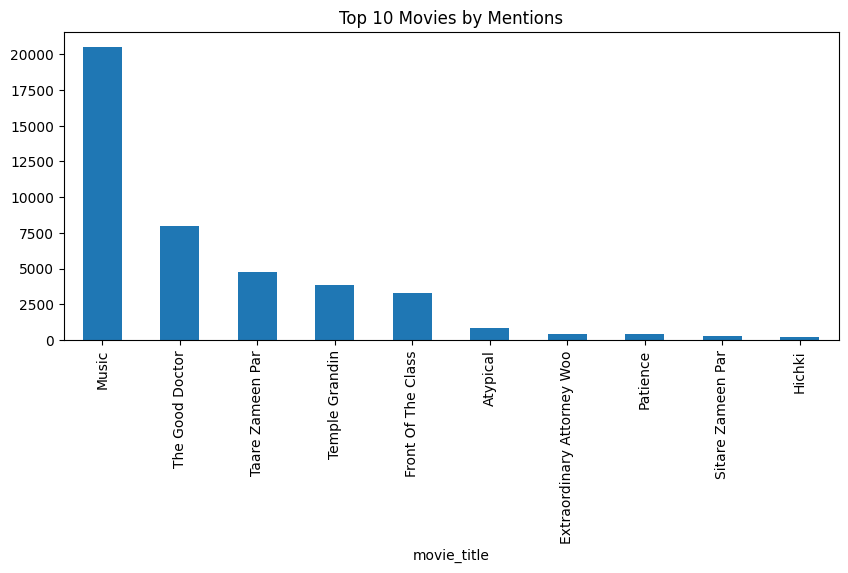

In [47]:
import matplotlib.pyplot as plt
master_df['movie_title'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title("Top 10 Movies by Mentions")
plt.show()


In [48]:
master_df['final_text'] = master_df['translated_text'].fillna(master_df['text'])

# Analysis

In [49]:
df = pd.read_csv('final_master_DB.csv')

In [50]:
df.head()

,movie_title,text,source,language,translated_text,cleaned_text,text_length,final_text
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian,en,Rain Man at 30: damaging stereotype or 'the be...,rain man damaging stereotype best thing happen...,5836,Rain Man at 30: damaging stereotype or 'the be...
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian,en,‘It was heartbreaking’: Family wins tribunal a...,‘it heartbreaking’ family win tribunal special...,5260,‘It was heartbreaking’: Family wins tribunal a...
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian,en,What Netflix comedy Atypical gets right and wr...,netflix comedy atypical get right wrong autism...,6136,What Netflix comedy Atypical gets right and wr...
3,Atypical,The sinister segregation policies excluding ch...,guardian,en,The sinister segregation policies excluding ch...,sinister segregation policy excluding child do...,5030,The sinister segregation policies excluding ch...
4,Atypical,This week’s best home entertainment: from Vani...,guardian,en,This week’s best home entertainment: from Vani...,week’s best home entertainment vanity fair hot...,1764,This week’s best home entertainment: from Vani...


In [51]:
df= df[['movie_title', 'source','cleaned_text']].rename(columns={'cleaned_text':'text'})

In [52]:
df.head()

,movie_title,source,text
0,Atypical,guardian,rain man damaging stereotype best thing happen...
1,Atypical,guardian,‘it heartbreaking’ family win tribunal special...
2,Atypical,guardian,netflix comedy atypical get right wrong autism...
3,Atypical,guardian,sinister segregation policy excluding child do...
4,Atypical,guardian,week’s best home entertainment vanity fair hot...


## Sentiment Analysis

In [53]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

sentiment_summary = df.groupby('movie_title')['sentiment_score'].mean().sort_values(ascending=False)
print(sentiment_summary)


movie_title
Barfi                         0.760016
Extraordinary Attorney Woo    0.693333
My Name Is Khan               0.582943
The Tic Code                  0.567013
Patience                      0.535797
Koi... Mil Gaya               0.525732
Sitare Zameen Par             0.511566
The Good Doctor               0.395351
Hichki                        0.382708
Temple Grandin                0.370190
Taare Zameen Par              0.363890
Front Of The Class            0.342039
Atypical                      0.307868
Rain Man                      0.288239
Everything'S Gonna Be Okay    0.248311
Music                         0.024293
Name: sentiment_score, dtype: float64


In [54]:
def label_sentiment(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

In [55]:
df['sentiment_label'].value_counts()

sentiment_label
positive    24281
negative    12782
neutral      5927
Name: count, dtype: int64

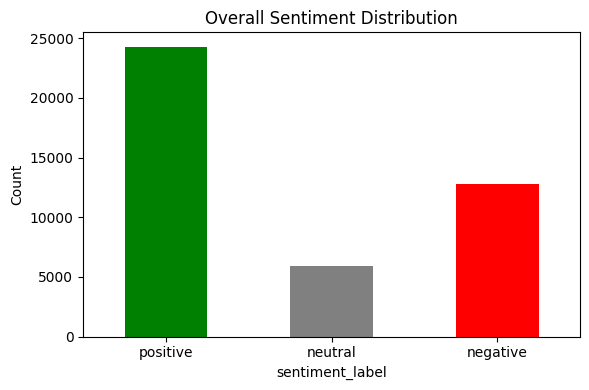

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['sentiment_label'].value_counts().reindex(['positive', 'neutral', 'negative']).plot(
    kind='bar', color=['green', 'grey', 'red']
)
plt.title('Overall Sentiment Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

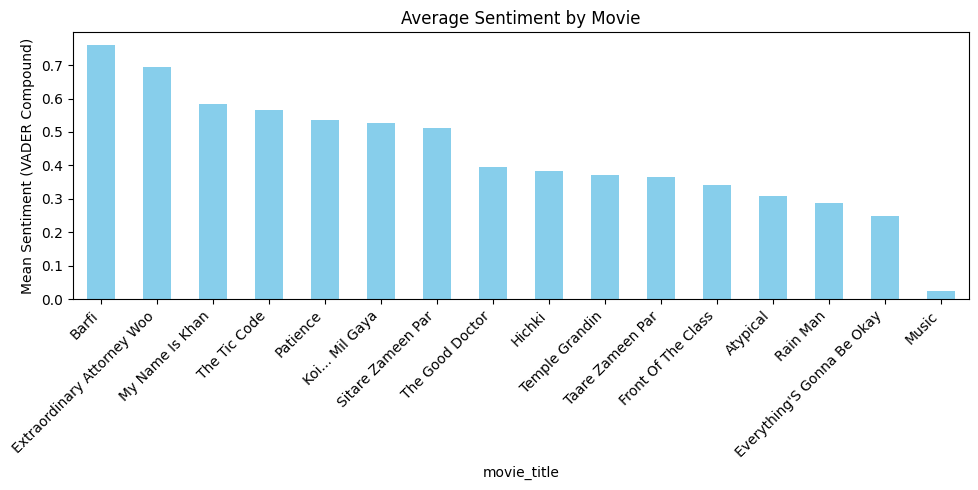

In [57]:
sentiment_by_movie = df.groupby('movie_title')['sentiment_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sentiment_by_movie.plot(kind='bar', color='skyblue')
plt.title('Average Sentiment by Movie')
plt.ylabel('Mean Sentiment (VADER Compound)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

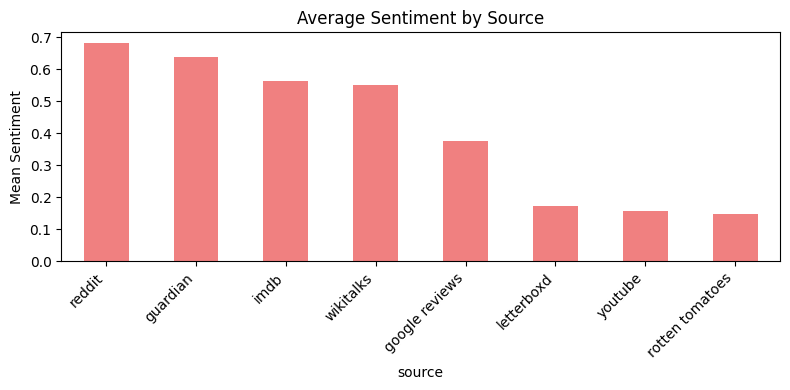

In [58]:
sentiment_by_source = df.groupby('source')['sentiment_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sentiment_by_source.plot(kind='bar', color='lightcoral')
plt.title('Average Sentiment by Source')
plt.ylabel('Mean Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

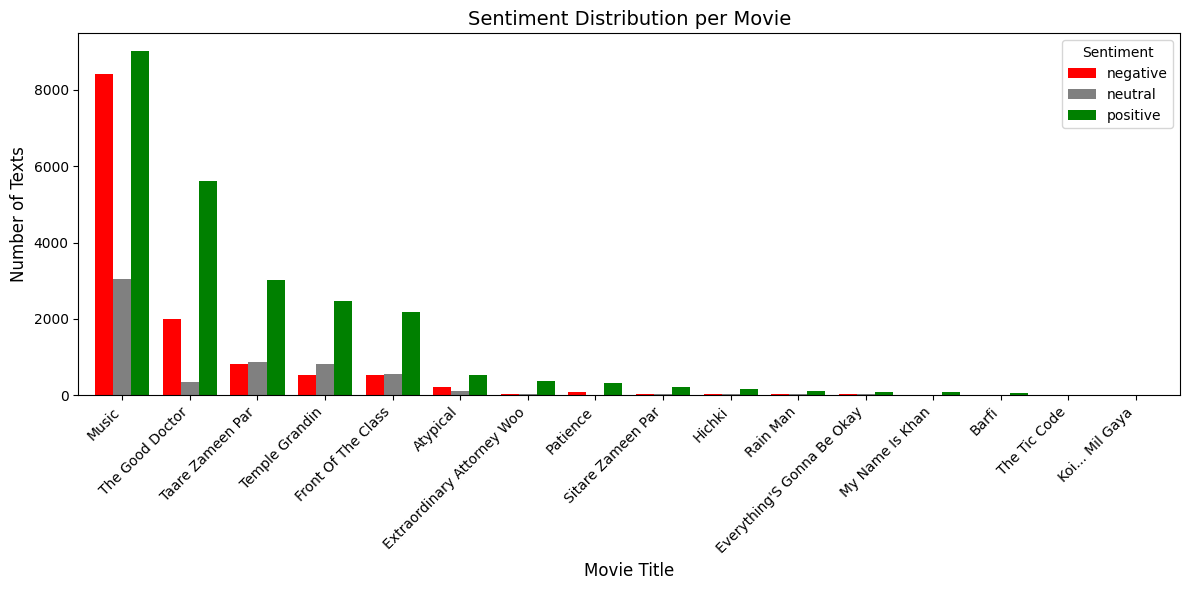

In [59]:
import pandas as pd

# Count of each sentiment category per movie
sentiment_counts = df.groupby(['movie_title', 'sentiment_label']).size().unstack(fill_value=0)

# Optional: sort movies alphabetically or by total reviews
sentiment_counts = sentiment_counts.loc[sentiment_counts.sum(axis=1).sort_values(ascending=False).index]

import matplotlib.pyplot as plt

# Set up figure
plt.figure(figsize=(12, 6))

# Plot grouped bars
sentiment_counts.plot(
    kind='bar',
    figsize=(12,6),
    color=['red', 'grey', 'green'],
    width=0.8
)

plt.title('Sentiment Distribution per Movie', fontsize=14)
plt.xlabel('Movie Title', fontsize=12)
plt.ylabel('Number of Texts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()


sentiment per unit of comment for better comparision/normalization.
pos/negative diided by total

how people are expressive. Control for 

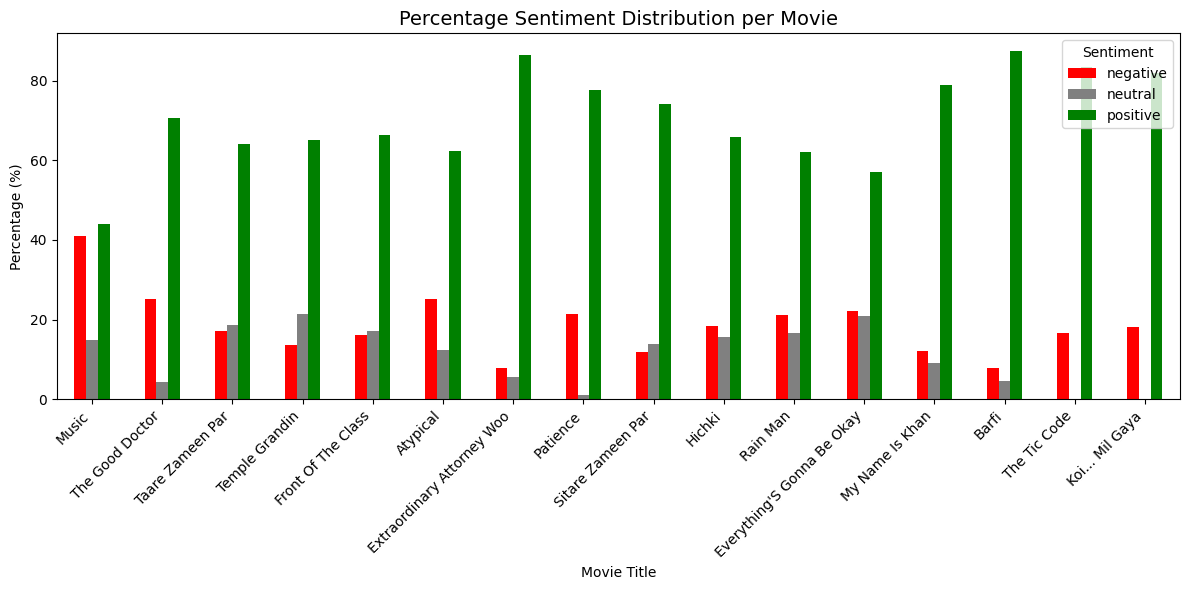

In [60]:
sentiment_percent = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

sentiment_percent.plot(
    kind='bar',
    stacked=False,
    figsize=(12,6),
    color=['red', 'grey', 'green']
)

plt.title('Percentage Sentiment Distribution per Movie', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel('Movie Title')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()


## Word Cloud

In [61]:
#!pip install wordcloud matplotlib

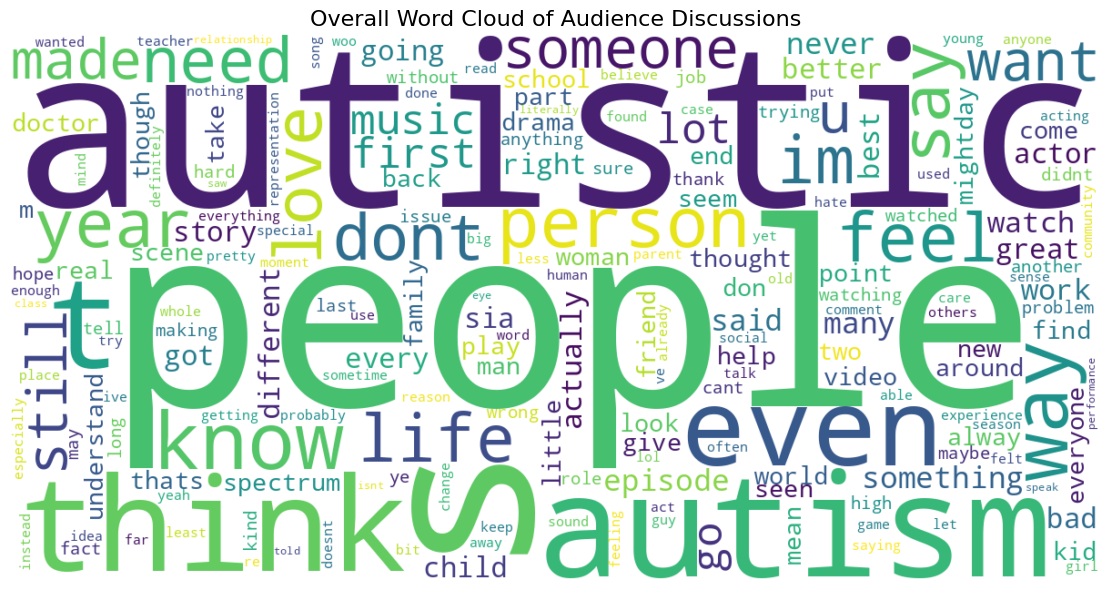

In [62]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

# Combine all cleaned text
all_text = " ".join(df['text'].dropna().astype(str))

# Define stopwords — add any words you want to exclude
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'movie', 'film', 'series', 'character', 'show',
    'one', 'also', 'get', 'see', 'really', 'make',
    'like', 'good', 'well', 'much', 'thing', 'time'
])

# Create the word cloud object
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,
    collocations=False,   # prevents joining of common phrases like “New York”
    colormap='viridis'    # color palette
).generate(all_text)

# Display the word cloud
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Overall Word Cloud of Audience Discussions", fontsize=16)
plt.tight_layout()
plt.show()

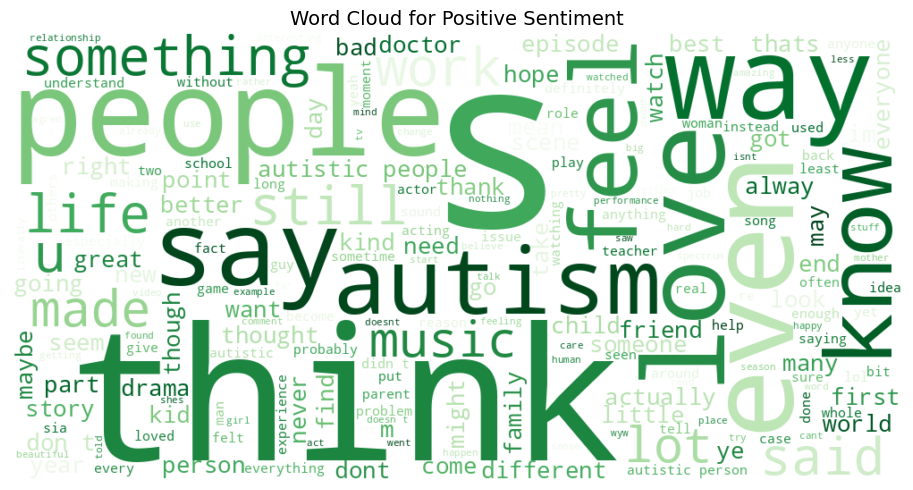

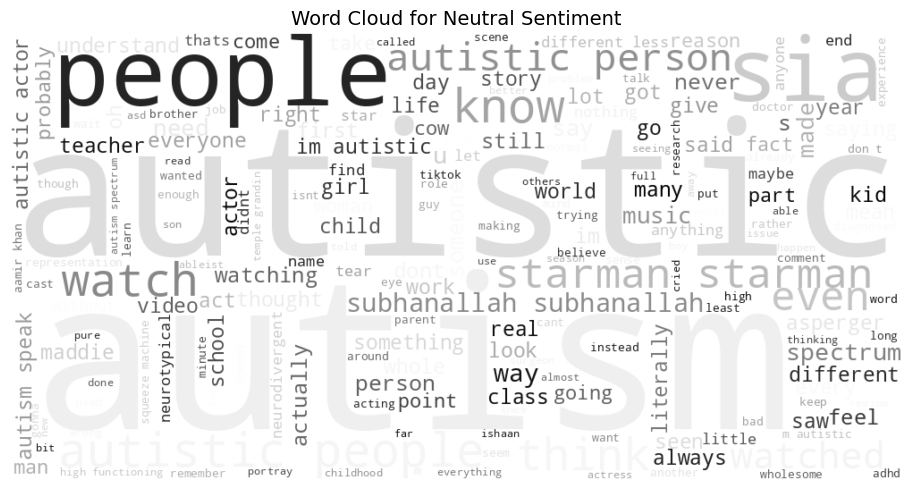

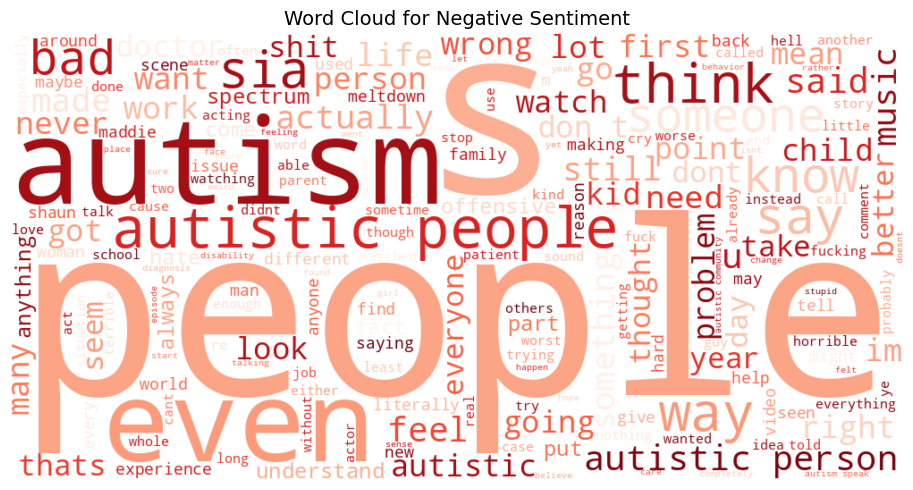

In [63]:
# Generate separate word clouds for positive, neutral, and negative sentiments
sentiments = ['positive', 'neutral', 'negative']

for sentiment in sentiments:
    subset = df[df['sentiment_label'] == sentiment]
    text = " ".join(subset['text'].dropna().astype(str))
    
    if len(text.split()) < 10:  # skip if too few words
        continue
    
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        stopwords=custom_stopwords,
        colormap='Greens' if sentiment == 'positive'
                  else 'Greys' if sentiment == 'neutral'
                  else 'Reds'
    ).generate(text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {sentiment.capitalize()} Sentiment", fontsize=14)
    plt.tight_layout()
    plt.show()


## Emotion Analysis

In [64]:
#!pip install nrclex matplotlib pandas tqdm

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from nrclex import NRCLex
from tqdm import tqdm

# Optional: enable progress bars for large datasets
tqdm.pandas()

# Function to extract dominant emotions
def get_emotions(text):
    if not isinstance(text, str) or text.strip() == "":
        return None
    try:
        emotion = NRCLex(text)
        return emotion.raw_emotion_scores
    except:
        return None

# Apply to each text
df['emotion_scores'] = df['text'].progress_apply(get_emotions)

# Convert list of dicts into DataFrame
emotion_df = pd.json_normalize(df['emotion_scores']).fillna(0)

# Merge emotion columns back into main dataframe
df_emotions = pd.concat([df, emotion_df], axis=1)

df_emotions.head()

100%|██████████| 42990/42990 [00:10<00:00, 4136.55it/s] 


,movie_title,source,text,sentiment_score,sentiment_label,emotion_scores,negative,anger,fear,positive,anticipation,joy,trust,sadness,surprise,disgust
0,Atypical,guardian,rain man damaging stereotype best thing happen...,0.9918,positive,"{'negative': 34, 'anger': 14, 'fear': 23, 'pos...",34.0,14.0,23.0,66.0,36.0,24.0,39.0,11.0,16.0,7.0
1,Atypical,guardian,‘it heartbreaking’ family win tribunal special...,0.9359,positive,"{'anticipation': 53, 'disgust': 30, 'fear': 39...",79.0,15.0,39.0,98.0,53.0,45.0,98.0,49.0,15.0,30.0
2,Atypical,guardian,netflix comedy atypical get right wrong autism...,0.9981,positive,"{'negative': 41, 'trust': 62, 'sadness': 22, '...",41.0,8.0,20.0,76.0,30.0,23.0,62.0,22.0,9.0,8.0
3,Atypical,guardian,sinister segregation policy excluding child do...,0.9694,positive,"{'anger': 19, 'disgust': 11, 'fear': 31, 'nega...",64.0,19.0,31.0,91.0,44.0,49.0,69.0,24.0,2.0,11.0
4,Atypical,guardian,week’s best home entertainment vanity fair hot...,0.9891,positive,"{'anticipation': 11, 'joy': 11, 'positive': 26...",18.0,6.0,10.0,26.0,11.0,11.0,18.0,11.0,5.0,4.0


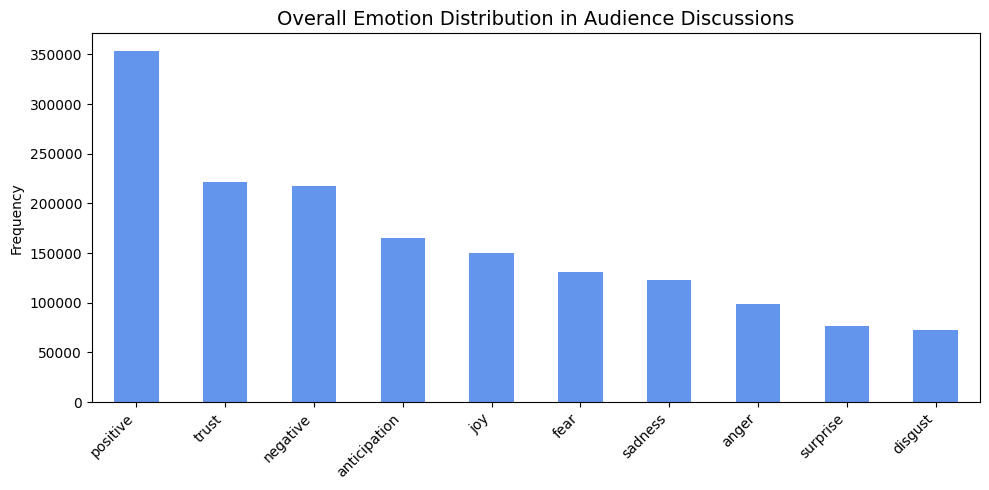

In [66]:
# Sum all emotion counts across dataset
emotion_totals = emotion_df.sum().sort_values(ascending=False)

# Plot overall emotion distribution
plt.figure(figsize=(10,5))
emotion_totals.plot(kind='bar', color='cornflowerblue')
plt.title("Overall Emotion Distribution in Audience Discussions", fontsize=14)
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

When you use the NRC Emotion Lexicon (NRCLex), it provides eight primary emotions based on Plutchik’s Wheel of Emotions, a widely accepted psychological model for emotional categorization in language.

*These eight are:*

- `Primary Emotion`:	Example Meaning / Usage
- `Anger`:	Hostility, frustration, moral outrage
- `Anticipation`:	Expectation, curiosity, hope
- `Disgust`:	Moral or aesthetic rejection, offense
- `Fear`:	Anxiety, threat perception
- `Joy`:	Happiness, admiration, gratitude
- `Sadness`:	Sympathy, sorrow, disappointment
- `Surprise`:	Shock, revelation, unexpectedness
- `Trust`:	Confidence, comfort, respect

👉 These emotions are balanced across positive, negative, and neutral spectrums and provide a robust yet interpretable representation of emotional tone.

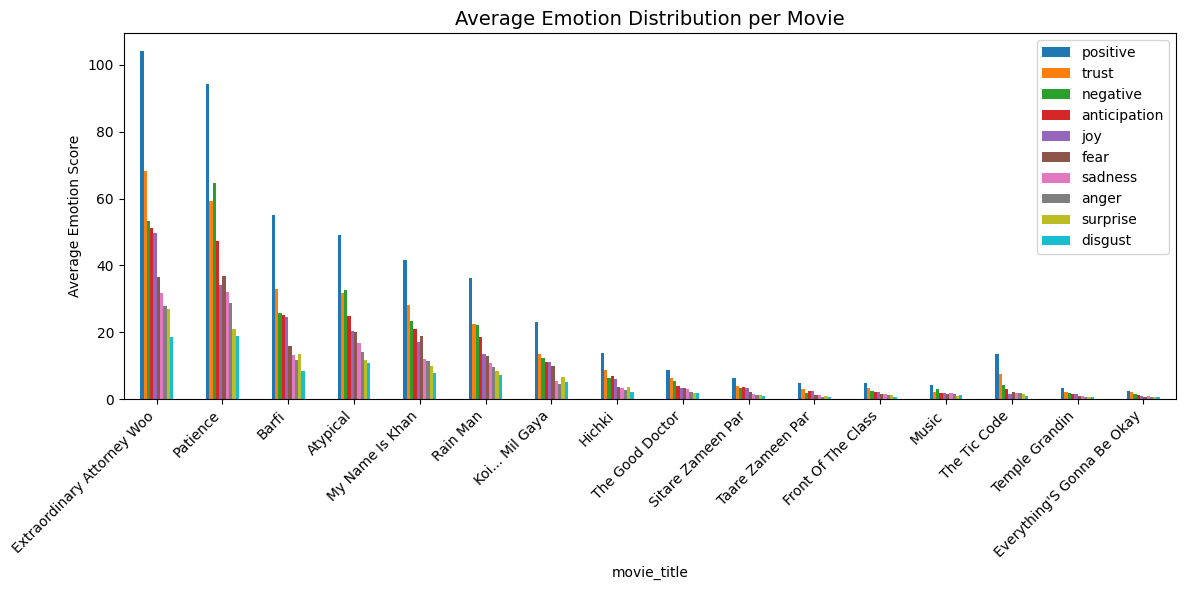

In [67]:
# Group by movie title and sum/average emotion columns
emotion_by_movie = df_emotions.groupby('movie_title')[emotion_totals.index].mean().sort_values('joy', ascending=False)

# Plot top emotions per movie
emotion_by_movie.plot(kind='bar', figsize=(12,6))
plt.title("Average Emotion Distribution per Movie", fontsize=14)
plt.ylabel("Average Emotion Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


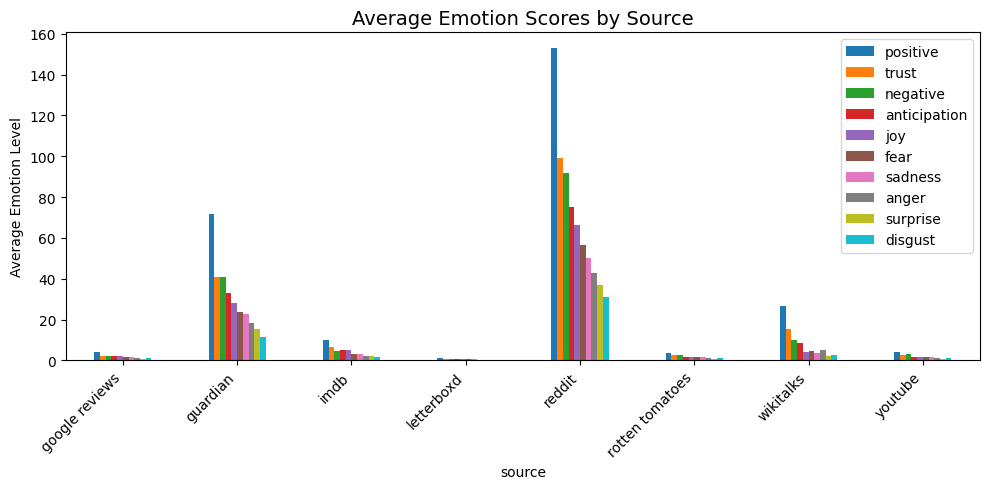

In [68]:
emotion_by_source = df_emotions.groupby('source')[emotion_totals.index].mean()

emotion_by_source.plot(kind='bar', figsize=(10,5))
plt.title("Average Emotion Scores by Source", fontsize=14)
plt.ylabel("Average Emotion Level")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


responses and emotion counts

In [69]:
def get_top_emotion(score_dict):
    if not isinstance(score_dict, dict) or len(score_dict) == 0:
        return None
    return max(score_dict, key=score_dict.get)

df_emotions['dominant_emotion'] = df_emotions['emotion_scores'].apply(get_top_emotion)
df_emotions['dominant_emotion'].value_counts()


dominant_emotion
positive        16017
negative         7009
anticipation     4037
trust            2757
anger            2508
joy              2321
fear             1589
disgust           592
sadness           298
surprise          202
Name: count, dtype: int64

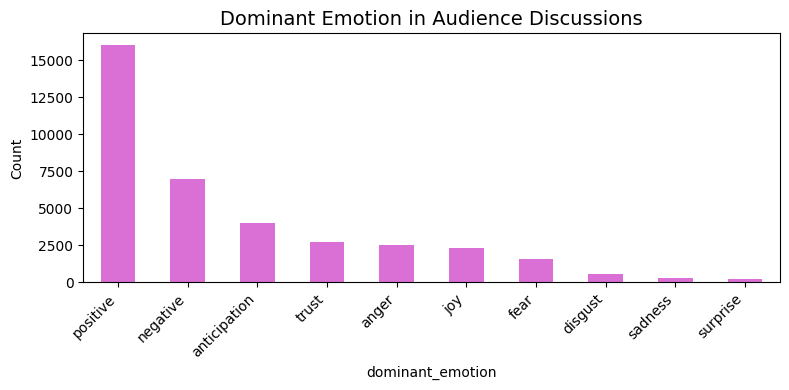

In [70]:
plt.figure(figsize=(8,4))
df_emotions['dominant_emotion'].value_counts().plot(kind='bar', color='orchid')
plt.title("Dominant Emotion in Audience Discussions", fontsize=14)
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Topic Modelling

In [71]:
#!pip install scikit-learn nltk spacy tqdm gensim pyldavis

In [72]:
#!python -m spacy download en_core_web_sm

In [73]:
#!pip install pyLDAvis

In [80]:
import re
import string
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

# NLP libs
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# -------------------------
# 1) Prepare text column
# -------------------------
# Use the cleaned/translated text column if you have one, otherwise 'text'
TEXT_COL = 'text'   # or 'final_text' if you created that earlier

# Ensure no NaNs and basic cleaning
df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)

# Optional lightweight normalisation
def basic_clean(text):
    text = text.lower()
    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    # remove emails
    text = re.sub(r'\S+@\S+', ' ', text)
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['topic_text'] = df[TEXT_COL].progress_apply(basic_clean)

# -------------------------
# 2) Lemmatize & remove stopwords (spaCy)
# -------------------------
stop_words = set(stopwords.words('english'))
# extend stopwords if needed
extra_stop = {'movie','film','character','show','episode','scene','one','like','see','watch'}
stop_words |= extra_stop

def lemmatize(text):
    if not text:
        return ''
    doc = nlp(text)
    tokens = []
    for token in doc:
        if token.is_alpha and not token.is_stop:
            lemma = token.lemma_.lower()
            if lemma not in stop_words and len(lemma) > 2:
                tokens.append(lemma)
    return ' '.join(tokens)

# This may take time for many rows; consider sampling for prototyping
df['topic_text_lem'] = df['topic_text'].progress_apply(lemmatize)

# Optionally inspect sample
df[['topic_text','topic_text_lem']].head()

# -------------------------
# 3) Vectorize - CountVectorizer for LDA
# -------------------------
# Tweak min_df/max_df and ngram_range to suit your corpus.
vectorizer = CountVectorizer(
    max_df=0.6,      # ignore very common terms
    min_df=5,        # ignore very rare terms
    max_features=20000,
    ngram_range=(1,2)
)

dtm = vectorizer.fit_transform(df['topic_text_lem'])

print("DTM shape:", dtm.shape)  # (n_docs, n_terms)

# -------------------------
# 4) Fit sklearn LDA
# -------------------------
n_topics = 5   
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=15,
    learning_method='online',
    random_state=42,
    batch_size=128,
    evaluate_every=-1,
    n_jobs=-1
)

lda.fit(dtm)

# -------------------------
# 5) Helpers to show topic keywords
# -------------------------
def display_topics(model, feature_names, n_top_words=12):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_idx]
        topics[topic_idx] = top_words
        print(f"Topic {topic_idx:02d}: {' | '.join(top_words)}")
    return topics

feature_names = vectorizer.get_feature_names_out()
topics = display_topics(lda, feature_names, n_top_words=12)

# -------------------------
# 6) Assign dominant topic to documents
# -------------------------
doc_topic_distr = lda.transform(dtm)   # doc x topic array
dominant_topic = np.argmax(doc_topic_distr, axis=1)
df['dominant_topic'] = dominant_topic
df['topic_prob'] = doc_topic_distr.max(axis=1)

# Show top documents per topic
for t in range(n_topics):
    print(f"\n--- Topic {t} sample docs (top 3 by topic prob) ---")
    sample = df[df['dominant_topic']==t].sort_values('topic_prob', ascending=False).head(3)
    print(sample[['movie_title','source','topic_prob','text']].to_string(index=False))

# -------------------------
# 7) Aggregate topic prevalence by movie or source
# -------------------------
topic_counts = df.groupby(['movie_title','dominant_topic']).size().unstack(fill_value=0)
topic_counts_norm = topic_counts.div(topic_counts.sum(axis=1), axis=0)  # normalized per movie

# show top topic for each movie
top_topic_by_movie = topic_counts.idxmax(axis=1).sort_values()
print(top_topic_by_movie)

# Save topics mapping for reporting
import json
with open('lda_topics.json','w') as f:
    json.dump(topics, f, indent=2)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gunturuvarsha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 42990/42990 [03:55<00:00, 182.24it/s] 


DTM shape: (42990, 20000)
Topic 00: people | work | school | need | child | say | help | life | year | way | time | thing
Topic 01: music | play | song | year | new | star | man | world | game | release | story | musical
Topic 02: good | love | story | great | cry | drama | woo | child | aamir | actor | temple | khan
Topic 03: think | know | feel | time | thing | get | love | want | good | way | bad | look
Topic 04: autistic | people | autism | person | autistic people | sia | think | spectrum | know | thing | way | autistic person

--- Topic 0 sample docs (top 3 by topic prob) ---
    movie_title  source  topic_prob                                                                                                                                                                                                                                                                                                                                                                                        

DTM shape: (42990, 20000)
Fitting LDA with 5 topics...
Fitting LDA with 6 topics...
Fitting LDA with 7 topics...
Fitting LDA with 8 topics...
Fitting LDA with 9 topics...
Fitting LDA with 10 topics...
Fitting LDA with 11 topics...
Fitting LDA with 12 topics...
Fitting LDA with 13 topics...
Fitting LDA with 14 topics...
Fitting LDA with 15 topics...
Fitting LDA with 16 topics...
Fitting LDA with 17 topics...
Fitting LDA with 18 topics...
Fitting LDA with 19 topics...


/Users/gunturuvarsha/Downloads/UG4_Sem7/IMP_data/venv/lib/python3.13/site-packages/sklearn/decomposition/_lda.py:147: RuntimeWarning: overflow encountered in dot
  doc_topic_d = exp_doc_topic_d * np.dot(cnts / norm_phi, exp_topic_word_d.T)
/Users/gunturuvarsha/Downloads/UG4_Sem7/IMP_data/venv/lib/python3.13/site-packages/sklearn/decomposition/_lda.py:147: RuntimeWarning: overflow encountered in dot
  doc_topic_d = exp_doc_topic_d * np.dot(cnts / norm_phi, exp_topic_word_d.T)
/Users/gunturuvarsha/Downloads/UG4_Sem7/IMP_data/venv/lib/python3.13/site-packages/sklearn/decomposition/_lda.py:147: RuntimeWarning: overflow encountered in dot
  doc_topic_d = exp_doc_topic_d * np.dot(cnts / norm_phi, exp_topic_word_d.T)
/Users/gunturuvarsha/Downloads/UG4_Sem7/IMP_data/venv/lib/python3.13/site-packages/sklearn/decomposition/_lda.py:147: RuntimeWarning: overflow encountered in dot
  doc_topic_d = exp_doc_topic_d * np.dot(cnts / norm_phi, exp_topic_word_d.T)
/Users/gunturuvarsha/Downloads/UG4_Sem7/

Fitting LDA with 20 topics...


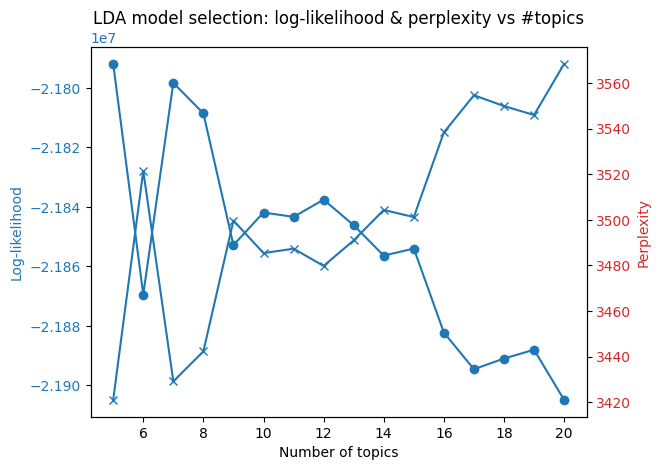

Best K by log-likelihood: 5
Best K by perplexity:    5


In [79]:
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation


# -------------------------
# Find optimal number of topics using sklearn metrics
# -------------------------
dtm = vectorizer.fit_transform(df['topic_text_lem'])
print("DTM shape:", dtm.shape)

topic_range = range(5, 21)  # e.g., try 5–20 topics
log_likelihoods = []
perplexities = []

for k in topic_range:
    print(f"Fitting LDA with {k} topics...")
    lda_k = LatentDirichletAllocation(
        n_components=k,
        max_iter=15,
        learning_method='online',
        random_state=42,
        batch_size=128,
        evaluate_every=-1,
        n_jobs=-1
    )
    lda_k.fit(dtm)
    
    # Higher score (log-likelihood) is better
    ll = lda_k.score(dtm)
    # Lower perplexity is better
    perp = lda_k.perplexity(dtm)

    log_likelihoods.append(ll)
    perplexities.append(perp)

# -------------------------
# Plot metrics
# -------------------------
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Number of topics')
ax1.set_ylabel('Log-likelihood', color=color)
ax1.plot(list(topic_range), log_likelihoods, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # second axis for perplexity
color = 'tab:red'
ax2.set_ylabel('Perplexity', color=color)
ax2.plot(list(topic_range), perplexities, marker='x')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('LDA model selection: log-likelihood & perplexity vs #topics')
plt.show()

# -------------------------
# Pick the "best" K
# -------------------------
best_k_ll = topic_range[int(np.argmax(log_likelihoods))]
best_k_perp = topic_range[int(np.argmin(perplexities))]

print(f"Best K by log-likelihood: {best_k_ll}")
print(f"Best K by perplexity:    {best_k_perp}")


In [81]:
# Gensim pipeline (tokenized input required)
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# Tokenize the lemmatized text (simple split)
texts = [doc.split() for doc in df['topic_text_lem'].tolist()]

# Build dictionary & corpus
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.6, keep_n=20000)
corpus = [dictionary.doc2bow(text) for text in texts]

# Train LDA
num_topics = 5
lda_gensim = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics,
                      random_state=42, passes=10, iterations=100)

# Print topics
for idx, topic in lda_gensim.print_topics(num_words=12):
    print(f"Topic: {idx} \nWords: {topic}\n")

# Compute coherence (u_mass or c_v)
coherence_model_lda = CoherenceModel(model=lda_gensim, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print("Gensim LDA coherence (c_v):", coherence_lda)


Topic: 0 
Words: 0.032*"good" + 0.024*"love" + 0.021*"story" + 0.016*"great" + 0.014*"cry" + 0.012*"feel" + 0.012*"beautiful" + 0.010*"life" + 0.010*"time" + 0.009*"amazing" + 0.009*"way" + 0.008*"think"

Topic: 1 
Words: 0.039*"music" + 0.021*"bad" + 0.012*"star" + 0.012*"fuck" + 0.011*"song" + 0.010*"good" + 0.010*"love" + 0.009*"musical" + 0.007*"girl" + 0.007*"think" + 0.007*"get" + 0.007*"shit"

Topic: 2 
Words: 0.022*"child" + 0.016*"teacher" + 0.014*"school" + 0.012*"time" + 0.012*"kid" + 0.011*"ishaan" + 0.011*"parent" + 0.010*"year" + 0.007*"khan" + 0.007*"class" + 0.007*"aamir" + 0.006*"know"

Topic: 3 
Words: 0.059*"temple" + 0.033*"grandin" + 0.023*"dane" + 0.018*"woman" + 0.018*"cow" + 0.017*"claire" + 0.012*"animal" + 0.011*"machine" + 0.009*"cattle" + 0.008*"biopic" + 0.008*"door" + 0.008*"squeeze"

Topic: 4 
Words: 0.039*"autistic" + 0.034*"people" + 0.029*"autism" + 0.014*"sia" + 0.013*"person" + 0.012*"think" + 0.010*"know" + 0.010*"thing" + 0.009*"way" + 0.008*"feel"

complexity v/s explanibility metric

In [ ]:
# === Topic Modeling with Gensim + pyLDAvis ===

# Install dependencies (run once in notebook if not already)
# !pip install gensim pyLDAvis nltk

import re
import string
import nltk
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora, models
from tqdm import tqdm
tqdm.pandas()

# Download resources (only first time)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# -------------------------------
# STEP 1 — CLEAN & PREPROCESS TEXT
# -------------------------------

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs, mentions, hashtags, and punctuation
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", " ", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and short tokens, then lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word.isalpha() and word not in stop_words and len(word) > 2]
    
    return tokens

# Apply preprocessing
df['tokens'] = df['text'].progress_apply(preprocess_text)

# -------------------------------
# STEP 2 — CREATE DICTIONARY & CORPUS
# -------------------------------

dictionary = corpora.Dictionary(df['tokens'])

# Filter extremes (optional): removes too rare/common words
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Create corpus (bag-of-words)
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

print(f"✅ Dictionary size: {len(dictionary)} unique tokens")
print(f"✅ Corpus size: {len(corpus)} documents")

# -------------------------------
# STEP 3 — BUILD LDA MODEL
# -------------------------------

num_topics = 5  # You can experiment with 5–10 depending on your dataset size

lda_model = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=15,
    alpha='auto',
    per_word_topics=True
)

# -------------------------------
# STEP 4 — PRINT TOPICS
# -------------------------------

print("\n🔍 Top Keywords per Topic:\n")
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"🟩 Topic {idx+1}:\n {topic}\n")

# -------------------------------
# STEP 5 — VISUALIZATION
# -------------------------------

# Create interactive visualization
vis = gensimvis.prepare(lda_model, corpus, dictionary)

# Display inside Jupyter
pyLDAvis.display(vis)

# Save to file for later
pyLDAvis.save_html(vis, 'lda_topic_modeling_all.html')
print("✅ Visualization saved as 'lda_topic_modeling_all.html'")


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/gunturuvarsha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gunturuvarsha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/gunturuvarsha/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
100%|██████████| 42990/42990 [00:15<00:00, 2698.15it/s] 


✅ Dictionary size: 21468 unique tokens
✅ Corpus size: 42990 documents

🔍 Top Keywords per Topic:

🟩 Topic 1:
 0.029*"autistic" + 0.027*"people" + 0.022*"autism" + 0.019*"like" + 0.011*"movie" + 0.011*"person" + 0.010*"sia" + 0.008*"even" + 0.008*"think" + 0.008*"character"

🟩 Topic 2:
 0.015*"music" + 0.007*"film" + 0.006*"song" + 0.005*"musical" + 0.005*"one" + 0.004*"first" + 0.004*"name" + 0.003*"character" + 0.003*"year" + 0.003*"world"

🟩 Topic 3:
 0.020*"show" + 0.017*"good" + 0.016*"like" + 0.013*"really" + 0.012*"love" + 0.009*"time" + 0.009*"watched" + 0.009*"episode" + 0.009*"doctor" + 0.007*"watch"

🟩 Topic 4:
 0.089*"movie" + 0.042*"film" + 0.018*"watch" + 0.015*"story" + 0.012*"good" + 0.011*"temple" + 0.011*"child" + 0.011*"one" + 0.010*"aamir" + 0.010*"great"

🟩 Topic 5:
 0.008*"school" + 0.008*"child" + 0.007*"like" + 0.007*"get" + 0.007*"year" + 0.007*"time" + 0.006*"one" + 0.006*"would" + 0.006*"life" + 0.006*"temple"

✅ Visualization saved as 'lda_topic_modeling_all.

- correlation between sentiment score and profit/revenue of the movie
- correlation between sentiment score and IMDB rating
- correlation between sentiment score and hollywood bollywood
- correlation between sentiment score and year of release
- regression y = profit/revenue